# Phase 1: Advanced EDA (v2)
### Understanding Dataset Geometry, Statistics, and Quality

This notebook provides a deep dive into the 50k unified dataset. Unlike basic EDA, we focus here on **Bounding Box (BBox) statistics** and **Spatial Distributions** which directly impact model training performance.

### 1. Environment Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fiftyone as fo
from pathlib import Path
from tqdm import tqdm

# --- Project Root Discovery ---
def get_project_root():
    current_path = Path().resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / "requirements.txt").exists():
            return parent
    return current_path

PROJECT_ROOT = get_project_root()
DATASET_DIR = PROJECT_ROOT / "data" / "processed" / "yolo_dataset"
YAML_PATH = DATASET_DIR / "data.yaml"
print(f"✅ Root identified: {PROJECT_ROOT}")

/home/chicken/Desktop/DesktopFiles/DL/AWD&TA/Real-Time-Weapon-Detection-Context-Aware-Red-Alert-System/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Root identified: /home/chicken/Desktop/DesktopFiles/DL/AWD&TA/Real-Time-Weapon-Detection-Context-Aware-Red-Alert-System


### 2. Loading Unified Dataset
We load the 'test' split for a representative statistical sample.

In [ ]:
dataset_name = "Weapon_Detection_Advanced_EDA"
if dataset_name in fo.list_datasets():
    fo.delete_dataset(dataset_name)

dataset = fo.Dataset.from_dir(
    dataset_dir=str(DATASET_DIR),
    yaml_path =YAML_PATH ,
    dataset_type=fo.types.YOLOv5Dataset,
    name=dataset_name,
    split="train"
)

print(f"Loaded {len(dataset)} images from the test split.")

  60% |███████/-----| 24673/41444 [25.0s elapsed, 19.7s remaining, 778.9 samples/s]   

### 3. Class Distribution Analysis
Understanding class imbalance is critical for setting Focal Loss weights.

/tmp/ipykernel_1725049/2874422009.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_df, x="Class", y="Count", palette="viridis")


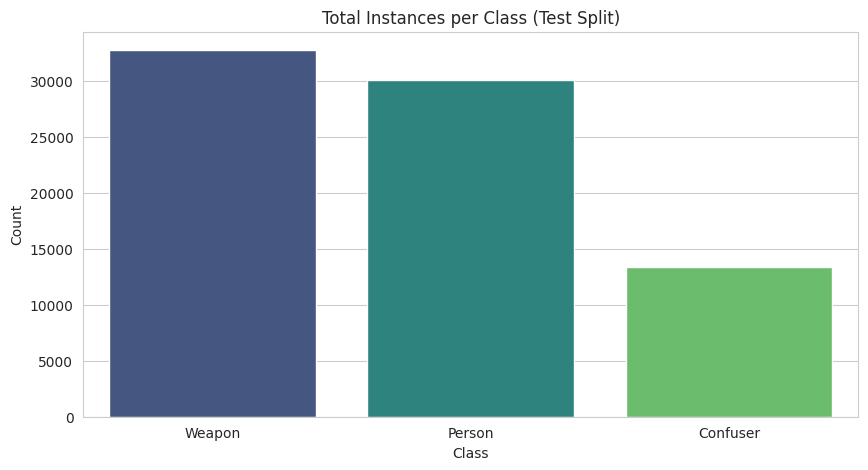

In [ ]:
# --- 3a. Class Distribution ---
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
class_counts = dataset.count_values("ground_truth.detections.label")
class_df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
sns.barplot(data=class_df, x="Class", y="Count", palette="viridis")
plt.title("Total Instances per Class (Test Split)")
plt.show()

### 3. Bounding Box Geometry Analysis
We extract every bounding box to analyze their **Relative Area** and **Aspect Ratio**.

Extracting BBoxes: 100%|██████████| 41444/41444 [00:57<00:00, 720.11it/s] 


{'label': 'Weapon', 'area': 0.05647286750000002, 'aspect_ratio': 0.6266885195660065, 'center_x': 0.5943749999999999, 'center_y': 0.7956821420204977}


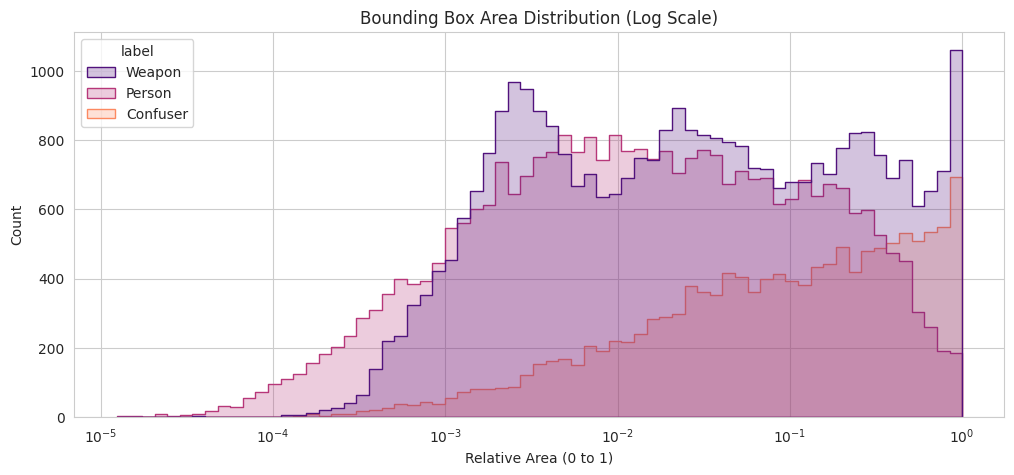

In [ ]:
bbox_data = []
for sample in tqdm(dataset, desc="Extracting BBoxes"):
    if sample.ground_truth:
        for det in sample.ground_truth.detections:
            # YOLO format in FiftyOne is [x_top_left, y_top_left, width, height] (normalized 0-1)
            w = det.bounding_box[2]
            h = det.bounding_box[3]
            bbox_data.append({
                "label": det.label,
                "area": w * h,
                "aspect_ratio": w / (h + 1e-6),
                "center_x": det.bounding_box[0] + (w/2),
                "center_y": det.bounding_box[1] + (h/2)
            })
print(bbox_data[0])
df = pd.DataFrame(bbox_data)

# Plot 1: Area Distribution
plt.figure(figsize=(12, 5))
sns.histplot(df, x="area", hue="label", element="step", palette="magma", log_scale=True)
plt.title("Bounding Box Area Distribution (Log Scale)")
plt.xlabel("Relative Area (0 to 1)")
plt.show()

### 4. Spatial Heatmaps (Detection Centers)
Where are weapons usually located in your frames?

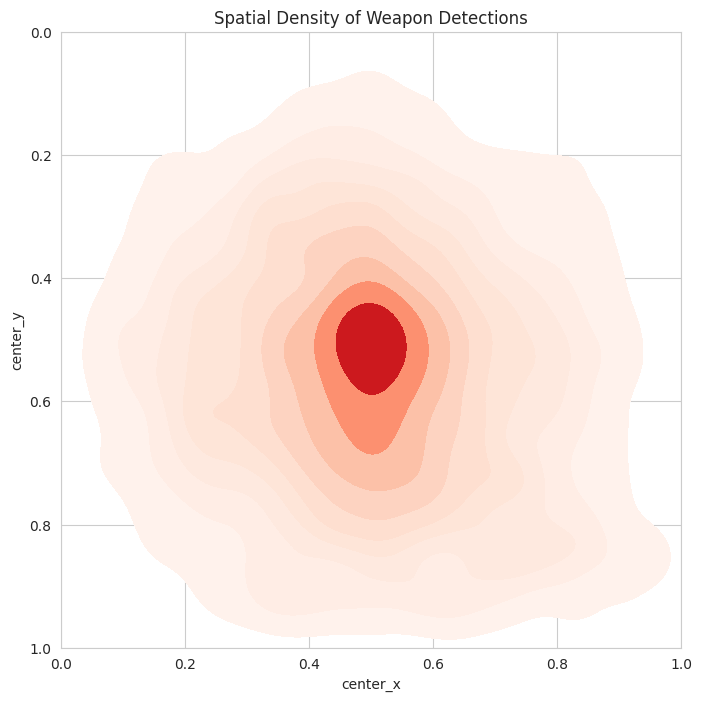

In [ ]:
plt.figure(figsize=(8, 8))
weapon_df = df[df['label'] == 'Weapon']
sns.kdeplot(data=weapon_df, x="center_x", y="center_y", cmap="Reds", fill=True, thresh=0.05)
plt.xlim(0, 1)
plt.ylim(1, 0) # Flip Y axis to match image coordinates
plt.title("Spatial Density of Weapon Detections")
plt.show()

### 6. Sample Visualization Grid
Static preview of ground truth annotations.

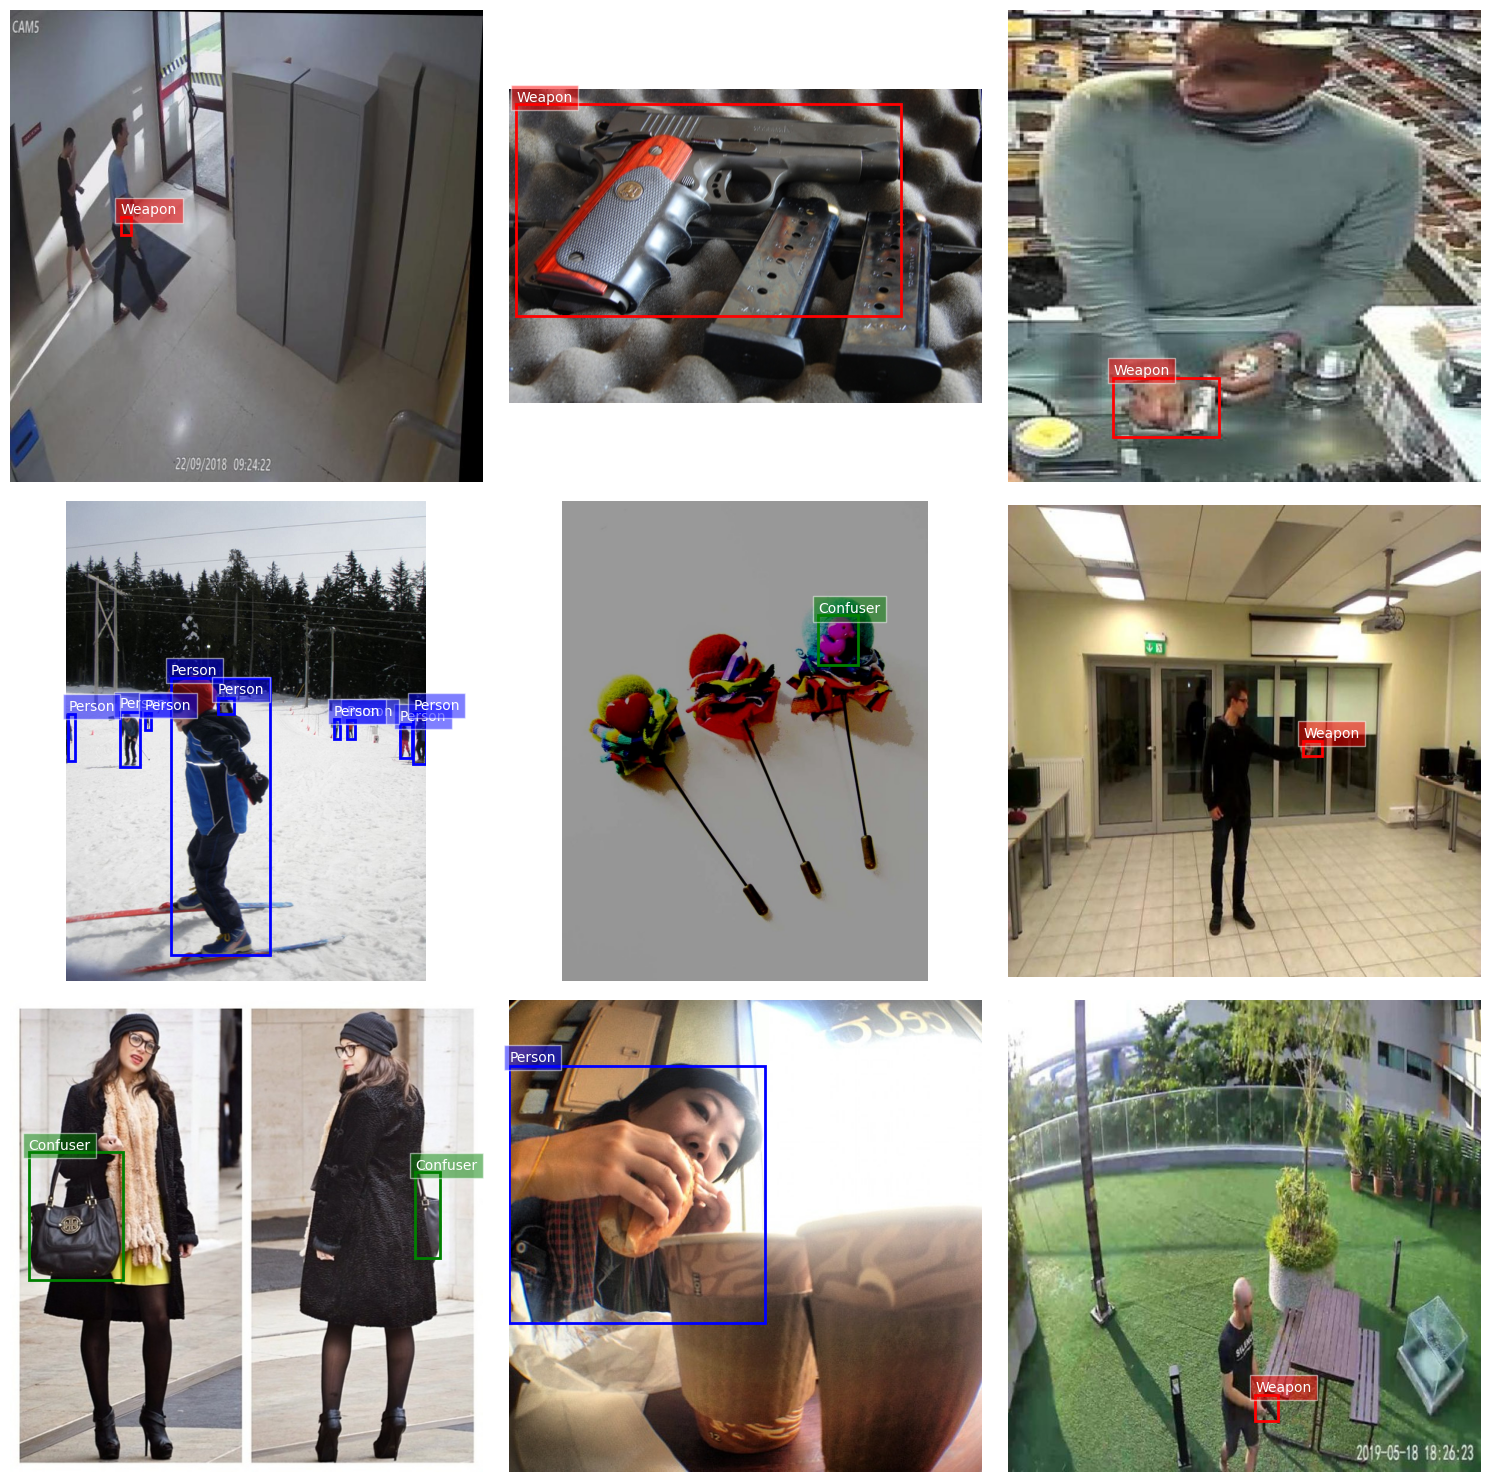

In [ ]:
import matplotlib.patches as patches
from PIL import Image

def draw_samples(dataset, num_samples=9):
    samples = dataset.take(num_samples)
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    
    # Map class names to colors
    colors = {"Weapon": "red", "Person": "blue", "Confuser": "green"}
    
    for i, sample in enumerate(samples):
        ax = axes[i//3, i%3]
        img = Image.open(sample.filepath)
        ax.imshow(img)
        w_img, h_img = img.size
        
        if sample.ground_truth:
            for det in sample.ground_truth.detections:
                x, y, w, h = det.bounding_box
                rect = patches.Rectangle(
                    (x * w_img, y * h_img), w * w_img, h * h_img, 
                    linewidth=2, edgecolor=colors.get(det.label, "white"), facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x * w_img, y * h_img - 5, det.label, color='white', 
                        fontsize=10, bbox=dict(facecolor=colors.get(det.label, "black"), alpha=0.5))
        
        ax.axis('off')
    plt.tight_layout()
    plt.show()

draw_samples(dataset)

### 5. Interactive Explorer (The FiftyOne App)
Use this to find the "Hardest" samples.

In [ ]:
# Launch App
# Close any existing sessions
fo.close_app()
session = fo.launch_app(dataset, port=5151)

print("🚀 EDA v2 Dashboard Ready.")
print("Learning Tip: Filter for 'Confuser' labels. These are the objects that might trigger false alarms.")

Connected to FiftyOne on port 5151 at localhost.
If you are not connecting to a remote session, you may need to start a new session and specify a port


🚀 EDA v2 Dashboard Ready.
Learning Tip: Filter for 'Confuser' labels. These are the objects that might trigger false alarms.
